# Food webs playground

Let's have fun!

## Installations

In [ ]:
# !pip install xmltodict
# !pip install pandas
# !pip install matplotlib
# !pip install geopandas shapely matplotlib requests pandas
# !pip install geodatasets

ERROR: Could not find a version that satisfies the requirement defaultdict (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for defaultdict


## Imports

In [3]:
import numpy as np
import requests
import xmltodict
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

## Basics

The urls are:

1. http://sirs.agrocampus-ouest.fr/EcoBase/php/webser/soap-client_3.php
2. http://sirs.agrocampus-ouest.fr/EcoBase/php/webser/soap-client.php
3. http://sirs.agrocampus-ouest.fr/EcoBase/php/webser/soap-client_output.php

To retrieve information of a specific model, we add its id at the end:

http://sirs.agrocampus-ouest.fr/EcoBase/php/webser/soap-client.php?no_model=227

### Difference Between *soap-client_3.php*, *soap-client* and *soap-client_output.php*

**soap-client_3.php:** Retrieves the **metadata and descriptions** of **all** EcoBase models.

**soap-client.php:** Given a specific model id, returns the full model metadata and data, including:
1. Group params (group_name, biomass, TL, PB, QB, etc.)
2. Diet composition / food web (diet_descr)

**soap-client_output.php:** Not publicly documented, and included in the others.
However, it does contain tl while th

### Notes:
1. Do not use "no_model=" on soap-client_3, it returns an incorrect result
2. For models with dissemination_allow=false, soap-client returns "Datas for this model are not available"

In [4]:
def download_xml_as_dict(url):
    response = requests.get(url)
    return xmltodict.parse(response.content)

def get_models_metadata_list():
    url = 'http://sirs.agrocampus-ouest.fr/EcoBase/php/webser/soap-client_3.php'
    response_dict = download_xml_as_dict(url)
    return response_dict['EcoBaseModels']['model_descr']

def get_model_metadata_inner(model_id):
    all_models = get_models_metadata_list()
    for model in all_models:
        if int(model['model']['model_number']) == model_id:
            return model

def get_model_data_inner(model_id):
    url = 'http://sirs.agrocampus-ouest.fr/EcoBase/php/webser/soap-client_output.php?no_model={}'.format(model_id)
    response_dict = download_xml_as_dict(url)
    if response_dict.get("EcoBaseModel", {}).get("Description") == "Datas for this model are not available":
        return "Datas for this model are not available"
    return response_dict["EcoBaseModel"]['group_descr']

def get_model_diet_data_inner(model_id):
    url = 'http://sirs.agrocampus-ouest.fr/EcoBase/php/webser/soap-client.php?no_model={}'.format(model_id)
    response_dict = download_xml_as_dict(url)
    if response_dict.get("EcoBaseModel", {}).get("Description") == "Datas for this model are not available":
        return "Datas for this model are not available"
    return response_dict["EcoBaseModel"]['group_descr']

# download models from xmls

In [5]:
model_datas = {}

model_metadatas = {}

all_models = get_models_metadata_list()

# for model in tqdm(all_models):
#     model_number = int(model['model']['model_number'])
#     model_datas[model_number] = get_model_data_inner(model_number)
#     model_metadatas[model_number] = get_model_metadata_inner(model_number)

In [ ]:
model_diet_datas = {}

for model in tqdm(all_models):
    model_number = int(model['model']['model_number'])
    model_diet_datas[model_number] = get_model_diet_data_inner(model_number)

In [ ]:
import json

def save_json_dict(dictionary, filename):
    # Open a file in write mode ('w')
    with open(f'{filename}.json', 'w') as json_file:
        # Use json.dump() to write the dictionary to the file
        json.dump(dictionary, json_file, indent=4) # indent makes it human-readable

In [ ]:
save_json_dict(model_metadatas, 'model_metadatas')
save_json_dict(model_datas, 'model_datas')
save_json_dict(model_diet_datas, 'model_diet_datas')

# Load datas from Json

In [6]:
import numpy as np
import requests
import xmltodict
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import json

def load_json_dict(filename):
    # Open a file in read mode ('r')
    with open(f'{filename}.json', 'r') as json_file:
        # Use json.load() to read the data and convert it back to a dictionary
        return json.load(json_file)

model_metadatas = load_json_dict('model_metadatas')
model_datas = load_json_dict('model_datas')
model_diet_datas = load_json_dict('model_diet_datas')

In [7]:
def get_model_metadata(model_id):
    return model_metadatas[str(model_id)]

def get_model_data(model_id):
    return model_datas[str(model_id)]

def get_model_diet_data(model_id):
    return model_diet_datas[str(model_id)]

In [8]:
# get_model_data(168)

# DB Overview

Total number of models: 386


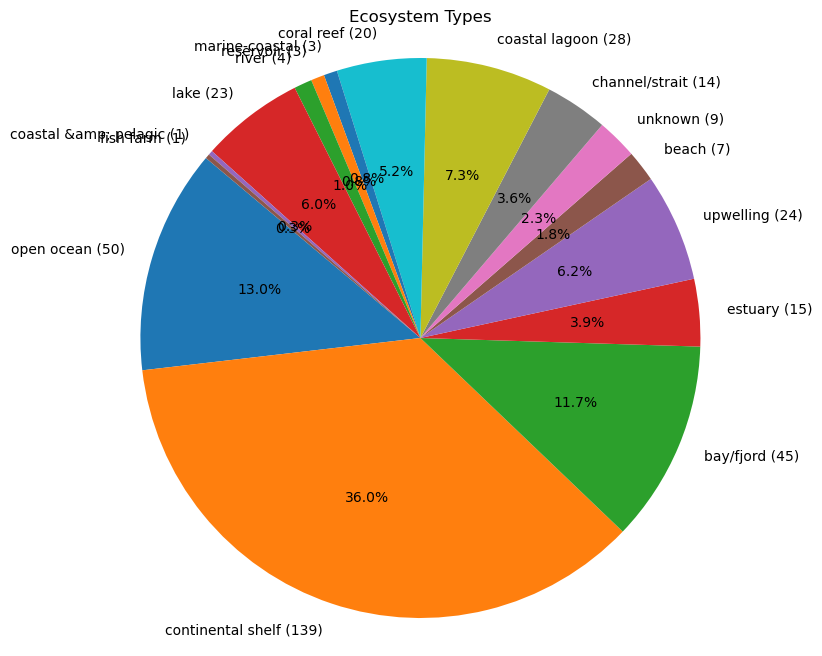

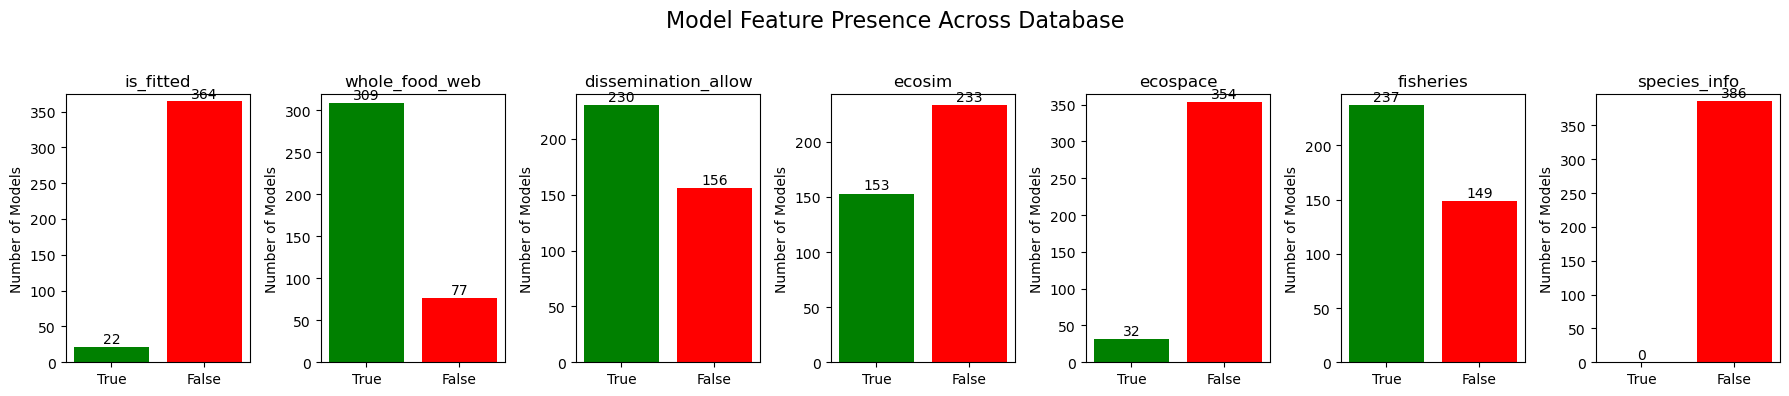


Feature: `is_fitted`
✅ True  (22 models): [727, 728, 729, 730, 732, 733, 734, 736, 739, 753, 754, 755, 756, 758, 759, 760, 765, 766, 767, 768, 776, 779]
❌ False (364 models): [2, 6, 7, 12, 16, 17, 22, 23, 24, 28, 29, 30, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 46, 48, 49, 50, 51, 53, 54, 57, 58, 60, 61, 63, 64, 66, 68, 72, 73, 74, 76, 81, 86, 92, 93, 95, 98, 99, 103, 105, 107, 108, 111, 112, 114, 115, 116, 118, 120, 121, 125, 126, 127, 129, 130, 132, 133, 134, 135, 136, 137, 140, 145, 146, 147, 149, 151, 153, 154, 155, 157, 158, 166, 168, 169, 172, 173, 174, 175, 179, 180, 181, 183, 184, 186, 188, 189, 190, 192, 193, 194, 195, 200, 201, 210, 216, 217, 218, 219, 221, 222, 224, 227, 229, 230, 232, 233, 234, 235, 236, 238, 239, 240, 241, 242, 243, 246, 247, 248, 252, 255, 256, 258, 260, 263, 265, 266, 267, 268, 269, 270, 273, 276, 279, 282, 283, 284, 289, 290, 291, 293, 298, 302, 304, 305, 307, 309, 311, 312, 318, 320, 322, 323, 324, 325, 328, 329, 332, 333, 335, 400, 401, 402, 4

In [9]:
# Fetch all models metadata
all_models = get_models_metadata_list()

# Total number of models
total_models = len(all_models)
print(f"Total number of models: {total_models}")

# Helper function to process boolean fields stored as string
def str_to_bool(s):
    return s.lower() == 'true'

# Prepare dictionaries for counting and storing model IDs
features = ['is_fitted', 'whole_food_web', 'dissemination_allow', 'ecosim', 'ecospace', 'fisheries', 'species_info']
feature_counts = {f: {'true': 0, 'false': 0} for f in features}
feature_models = {f: {'true': [], 'false': []} for f in features}

# Also keep track of ecosystem types for pie chart
ecosystem_type_counts = defaultdict(int)

# Process all models
for model in all_models:
    model = model["model"]
    model_id = int(model['model_number'])

    for f in features:
        val = model.get(f, 'false').lower()
        feature_counts[f][val] += 1
        feature_models[f][val].append(model_id)

    ecosystem_type = model.get('ecosystem_type', 'Unknown').lower()
    ecosystem_type_counts[ecosystem_type] += 1

# Pie chart of ecosystem types
labels = [f"{k} ({v})" for k, v in ecosystem_type_counts.items()]
sizes = list(ecosystem_type_counts.values())

plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Ecosystem Types')
plt.axis('equal')
plt.show()

# Plot 5 small bar charts
fig, axs = plt.subplots(1, 7, figsize=(18, 4))

for i, f in enumerate(features):
    true_count = feature_counts[f]['true']
    false_count = feature_counts[f]['false']

    axs[i].bar(['True', 'False'], [true_count, false_count], color=['green', 'red'])
    axs[i].set_title(f'{f}')
    axs[i].set_ylabel('Number of Models')
    axs[i].set_ylim(0, max(true_count, false_count) + 10)
    axs[i].text(0, true_count + 1, str(true_count), ha='center', va='bottom', fontsize=10)
    axs[i].text(1, false_count + 1, str(false_count), ha='center', va='bottom', fontsize=10)

plt.suptitle("Model Feature Presence Across Database", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Print sorted model ID lists
for f in features:
    true_list = sorted(feature_models[f]['true'])
    false_list = sorted(feature_models[f]['false'])

    print(f"\nFeature: `{f}`")
    print(f"✅ True  ({len(true_list)} models): {true_list}")
    print(f"❌ False ({len(false_list)} models): {false_list}")


## Missing Food-webs

There are 168 models with whole_food_web and dissemination_allow


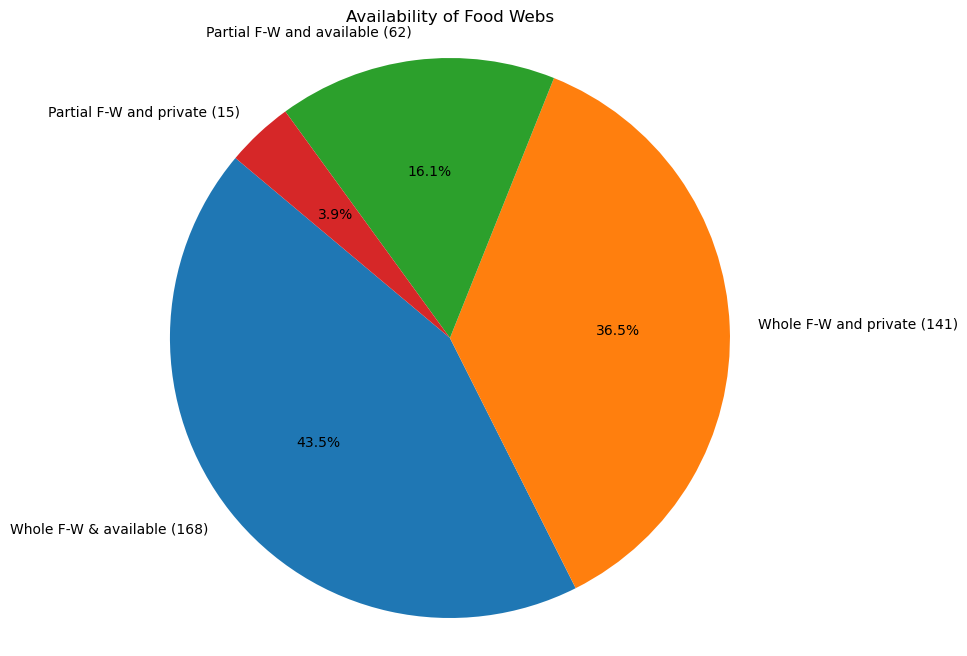

In [10]:
categories = ["Whole F-W & available", "Whole F-W and private", "Partial F-W and available", "Partial F-W and private"]
features_existance = [('true', 'true'), ('true', 'false'), ('false', 'true'), ('false', 'false')]
ids_per_category = []

for i in range(len(features_existance)):
    fw, pub = features_existance[i]
    features_cut = sorted(list(set(feature_models['whole_food_web'][fw]) & set(feature_models['dissemination_allow'][pub])))
    ids_per_category.append(features_cut)

sizes = [len(ids_lst) for ids_lst in ids_per_category]

print("There are {} models with whole_food_web and dissemination_allow".format(sizes[0]))

labels = ["{} ({})".format(categories[i], sizes[i]) for i in range(len(categories))]
plt.figure(figsize=(10, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
plt.title('Availability of Food Webs')
plt.axis('equal')
plt.show()


In [11]:
# print ids of private whole food webs
for model_id in ids_per_category[0]:
    model = get_model_metadata(model_id)["model"]
    print("{0} | {1} ({2})".format(model.get("model_number"), model.get("model_name"), model.get("model_year")))

2 | Alaska, Prince William Sound (1980)
7 | Azores archipelago (1997)
24 | Caribbean (1980)
28 | Central Atlantic (1950)
29 | Central Atlantic (1990)
34 | Chesapeake (1950)
40 | Eastern Scotian Shelf (1980)
41 | Eastern Scotian Shelf (1995)
46 | Denmark, Faroe Islands (1997)
48 | Galapagos, Floreana rocky reef (2000)
53 | Golfo Dulce (1993)
58 | Gulf of Mexico (1980)
63 | Barents Sea (1990)
64 | Low Barents sea (1995)
68 | Icelandic shelf (1997)
99 | USA, Mid Atlantic Bight (1995)
105 | Grand Banks of Newfoundland (1900)
107 | Grand Banks of Newfoundland (1980)
108 | Grand Banks of Newfoundland (1990)
111 | North Atlantic (1950)
112 | North Atlantic (1997)
115 | Northern Benguela (1956)
116 | Northern Gulf St Lawrence (1985)
118 | Northwest Africa (1987)
125 | Ria Formosa (1996)
133 | Senegambia (1990)
135 | Sierra Leone (1964)
136 | Sierra Leone 1978 (1978)
137 | Sierra Leone (1990)
145 | Southern Gulf of St. Lawrence (1980)
153 | Tampa Bay (1950)
168 | Greenland, West Coast (1997)
17

## Get Model By Name

In [12]:
for model in all_models:
    model = model["model"]
    if "Iceland" in model["model_name"]:
        print(model)
        print("====================")

# biscay_1970 = get_model_data(633)
# biscay_1998 = get_model_data(634)
# biscay_1994 = get_model_data(335)

# iceland_1950 = get_model_data(227)

# display_model_output_table(biscay_1998)
# biscay_1980 = 736  # not whole food web
# biscay_2013 = 737  # not whole food web


{'model_number': '227', 'model_name': 'Iceland', 'country': 'Iceland', 'area': '376766', 'region': '27', 'lme': '59', 'geographic_extent': 'BOX(-27 62,-11 68)', 'ecosystem_type': 'open ocean', 'currency_units': 'WetWeight', 'currency_units_custom': 'false', 'description': 'Eny: Pedigree index = 0.16442, t* = 0.76. This is the 1950 Icelandic model for ICES Area VA (= 376,766 km2). The structure of the model follows exactly the structure of the 1997 model (originally built by Asberr Natoumby Mendy). The landing data were taken from 1950 SAUP database (with adjustment included), and complemented with Icelandic national catch database where necessary. Six fishing fleets did not exist in 1950 but exist in 1997, they are Danish Seine, Midwater Trawl, Lobster Trawl, Capelin Seine, Capelin Midwater Trawl, and Shrimp Trawl. Thus, I included these six fleets in the 1950 model as dummy fleets. The catches of these dummy fleets in 1950 were taken from the cathes of the 1997 model, keeping the catc

## Existance of URLs for Models

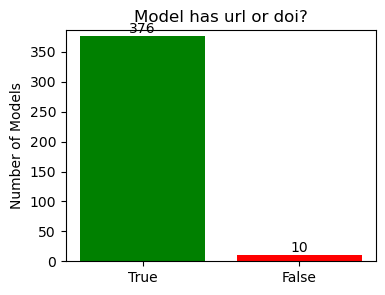

In [13]:
all_models = get_models_metadata_list()

has_url_counts = {True: 0, False: 0}
has_url_models = {True: [], False: []}

# Process all models
for model in all_models:
    model = model["model"]
    model_id = int(model['model_number'])

    val = "url" in model or 'doi' in model
    has_url_counts[val] += 1
    has_url_models[val].append(model_id)

true_count = has_url_counts[True]
false_count = has_url_counts[False]

plt.figure(figsize=(4, 3))
plt.bar(['True', 'False'], [true_count, false_count], color=['green', 'red'])
plt.title(f'Model has url or doi?')
plt.ylabel('Number of Models')
plt.ylim(0, max(true_count, false_count) + 10)
plt.text(0, true_count + 1, str(true_count), ha='center', va='bottom', fontsize=10)
plt.text(1, false_count + 1, str(false_count), ha='center', va='bottom', fontsize=10)
plt.show()

I checked the 10 models without url:
1. All of them are dissemination_allow=False
2. Only one is whole_food_web=True

## Match Species to Source Model

In [14]:
from dataclasses import dataclass

@dataclass
class SpeciesGroup:
    group_name: str
    group_seq: int
    model_number: int
    model_name: str
    model_country: str
    model_year: str
    lme: int
    tl: float
    biomass: float
    pb: float
    qb: float
    ee: float
    M0b: float
    flow_to_det: float
    gross_efficiency: float
    prop_unassimilated_food: float
    respiration: float
    biomass_accum: float
    biomass_accum_rate: float
    immigration: float
    emigration: float
    export: float
    diet_import: float
    trophic_info: str
    detritus_import: float
    taxons_included: list[dict] 

    @classmethod
    def from_dict(cls, data: dict):
        """Factory method to create an instance from a dictionary."""
        return cls(**data)

    def __str__(self):
        return f"[{self.model_number}] '{self.model_name}' {self.model_country} ({self.model_year}) -> {self.group_seq}: {self.group_name} | tl: {self.tl}, taxons included: {[self.taxons_included[i]['taxon_name'] + ' (' + self.taxons_included[i]['AphiaID'] + ')' for i in range(len(self.taxons_included))]}"
    
    def to_df_row(self):
        dct = self.__dict__.copy()
        dct.pop("taxons_included")
        return pd.DataFrame(dct)

def encoder(obj):
    return obj.__dict__

def save_json_SpeciesGroup_list(dictionary, filename):
    # Open a file in write mode ('w')
    with open(f'{filename}.json', 'w') as json_file:
        # Use json.dump() to write the dictionary to the file
        json.dump(dictionary, json_file, default=encoder, indent=4) # indent makes it human-readable

def decoder(dct):
    return SpeciesGroup.from_dict(dct)

def read_json_SpeciesGroup_list(filename):
    # Open the JSON file and load the data
    with open(f'{filename}.json', 'r') as f:
        # Use json.load and specify the object_hook
        return json.load(f, object_hook=decoder)

In [15]:
groups = []

for model_id in ids_per_category[0]:  # whole FW & available
    data = pd.DataFrame(get_model_data(model_id)["group"])
    metadata = get_model_metadata(model_id)["model"]
    diet_data = get_model_diet_data(model_id)["group"]
    for j, group in enumerate(diet_data):
        group_diet_data = diet_data[j]
        group_data = data[data['group_seq'].astype(int) == int(group_diet_data["group_seq"])].to_dict(orient='records')[0]
        group_info = {
            "group_name": group_diet_data["group_name"],
            "group_seq": int(group_diet_data["group_seq"]),
            "model_number": int(model_id),
            "model_name": metadata["model_name"],
            "model_country": metadata["country"],
            "model_year": metadata["model_year"],
            "lme": metadata.get("lme", None),
            "tl": float(group_data["tl"]),
            "biomass": float(group_diet_data["biomass"]) if group_diet_data.get("biomass", np.nan) != "-9999" else np.nan,
            "pb": float(group_diet_data["pb"]) if group_diet_data.get("pb", np.nan) != "-9999" else np.nan,
            "qb": float(group_diet_data["qb"]) if group_diet_data.get("qb", np.nan) != "-9999" else np.nan,
            "ee": float(group_diet_data["ee"]) if group_diet_data.get("ee", np.nan) != "-9999" else np.nan,
            "M0b": float(group_data["other_mort"]) if group_data.get("other_mort") != "-9999" else np.nan,
            "gross_efficiency": float(group_diet_data.get("ge", np.nan)) if group_diet_data.get("ge", np.nan) != "-9999" else np.nan,
            "prop_unassimilated_food": float(group_diet_data.get("gs", np.nan)) if group_diet_data.get("gs", np.nan) != "-9999" else np.nan,
            "respiration": float(group_diet_data.get("respiration", np.nan)) if group_diet_data.get("respiration", np.nan) != "-9999" else np.nan,
            "immigration": float(group_diet_data.get("immigration", np.nan)) if group_diet_data.get("immigration", np.nan) != "-9999" else np.nan,
            "emigration": float(group_diet_data.get("emigration", np.nan)) if group_diet_data.get("emigration", np.nan) != "-9999" else np.nan,
            "biomass_accum": float(group_diet_data.get("biomass_accum", np.nan)) if group_diet_data.get("biomass_accum", np.nan) != "-9999" else np.nan,
            "biomass_accum_rate": float(group_diet_data.get("biomass_accum_rate", np.nan)) if group_diet_data.get("biomass_accum_rate", np.nan) != "-9999" else np.nan,
            "export": float(group_diet_data.get("export", np.nan)) if group_diet_data.get("ge", np.nan) != "-9999" else np.nan,
            "trophic_info": (lambda x: ["Regular", "PP", "DET"][int(x)])(float(group_diet_data["pp"])),
            "detritus_import": float(group_diet_data.get("detritus_import", 0)) if group_diet_data["pp"] == "2" else 0,
            "diet_import": float(group_diet_data.get("diet_imp", np.nan)) if group_diet_data.get("diet_imp", np.nan) != "-9999" else np.nan,
        }
        group_info["taxons_included"] = []
        taxon_descr = group_diet_data["taxon_descr"]
        if isinstance(taxon_descr, dict):
            taxon_descr = [taxon_descr]
        elif isinstance(taxon_descr, list):
            for i in range(len(taxon_descr)):
                group_info["taxons_included"].append(
                    {
                        "taxon_name": group_diet_data["taxon_descr"]["taxon"][i]["taxon_name"],
                        "taxon_class": group_diet_data["taxon_descr"]["taxon"][i]["taxon_class"],
                        "taxon_order": group_diet_data["taxon_descr"]["taxon"][i]["taxon_order"],
                        "taxon_family": group_diet_data["taxon_descr"]["taxon"][i]["taxon_family"],
                        "taxon_genus": group_diet_data["taxon_descr"]["taxon"][i]["taxon_genus"],
                        "taxon_species": group_diet_data["taxon_descr"]["taxon"][i]["taxon_species"],
                        "AphiaID": group_diet_data["taxon_descr"]["taxon"][i]["source_key"],
                        "WoRMS_url": f"https://www.marinespecies.org/aphia.php?p=taxdetails&id={int(group["taxon_descr"]["taxon"][i]["source_key"])}",
                        "prop_biomass": group_diet_data["taxon_descr"]["taxon"][i]["prop_biomass"],
                        "prop_catch": group_diet_data["taxon_descr"]["taxon"][i]["prop_catch"],
                    }
                )
        
        if group_diet_data["ee"] == "-9999":
            group_info["ee"] = float(group_data["ee"])
        
        # flow to det = flow from unassimilated food + flow from other mortality
        group_info['M0b'] = group_info['pb'] * (1-group_info['ee'])
        flow_from_food = group_info["biomass"] * group_info["qb"] * group_info["prop_unassimilated_food"]
        flow_from_bodies = group_info["biomass"] * group_info["M0b"]
        group_info['flow_to_det'] = flow_from_food + flow_from_bodies

        groups.append(SpeciesGroup.from_dict(group_info))

In [16]:
save_json_SpeciesGroup_list(groups, "SpeciesGroups")

In [17]:
species_groups = read_json_SpeciesGroup_list("SpeciesGroups")

In [ ]:
species_groups